In [1]:
import pandas as pd
df = pd.read_csv('./data/ab_test_results_aggregated_views_clicks_3.csv')
print(df.head())

   user_id    group  views  clicks
0        1  control    3.0     0.0
1        2  control    2.0     0.0
2        3  control    2.0     0.0
3        4  control    2.0     0.0
4        5  control    5.0     0.0


In [ ]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   user_id  90000 non-null  int64  
 1   group    90000 non-null  object 
 2   views    90000 non-null  float64
 3   clicks   90000 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 2.7+ MB


,user_id,views,clicks
count,90000.000000,90000.000000,90000.000000
mean,45000.500000,5.011522,0.278367
std,25980.906451,5.899868,0.612277
min,1.000000,1.000000,0.000000
25%,22500.750000,2.000000,0.000000
50%,45000.500000,3.000000,0.000000
75%,67500.250000,6.000000,0.000000
max,90000.000000,204.000000,14.000000


In [ ]:
# check balance
df.groupby('group')['user_id'].count()

group
control    45000
test       45000
Name: user_id, dtype: int64

In [3]:
df.isnull().sum()

user_id    0
group      0
views      0
clicks     0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

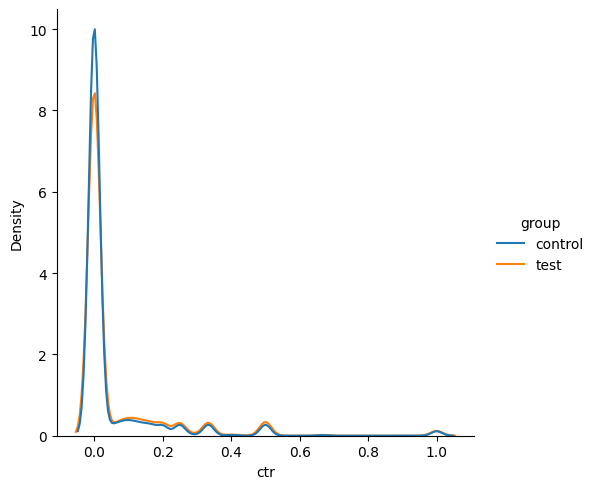

In [5]:
# distribution
import seaborn as sns
df['ctr'] = df['clicks'] / df['views']
sns.displot(data=df,x='ctr',hue='group',kind='kde')

<Axes: xlabel='group', ylabel='ctr'>

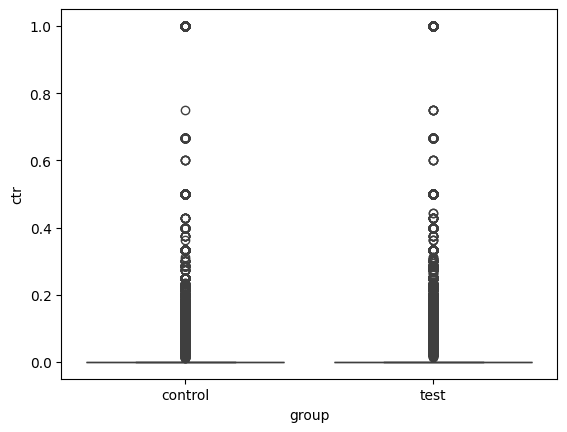

In [6]:
sns.boxplot(x='group',y='ctr',data=df)

In [8]:
df.groupby('group')[['views','clicks','ctr']].mean()

,views,clicks,ctr
group,,,
control,5.024467,0.244622,0.048464
test,4.998578,0.312111,0.062712


## bootstrap method

In [9]:
import numpy as np
def bootstrap_ctr_diff(df,group_col='group', clicks_col='clicks', views_col='views', n_boost=5000):
    control = df[df[group_col] == 'control']
    treatment = df[df[group_col] == 'test']
    diffs = []
    for _ in range(n_boost):
        c = control.sample(len(control), replace=True)
        t = treatment.sample(len(treatment), replace=True)
        c_ctr = c[clicks_col].sum() / c[views_col].sum()
        t_ctr = t[clicks_col].sum() / t[views_col].sum()
        diffs.append(t_ctr - c_ctr)
    lower,upper = np.quantile(diffs, [0.025,0.975])
    p_value = max(np.mean(np.array(diffs) <= 0), 1/len(np.array(diffs)))

    return np.mean(diffs), lower, upper, p_value, diffs

In [10]:
result = bootstrap_ctr_diff(df)
print(result[3])

0.0002


<Figure size 400x200 with 0 Axes>

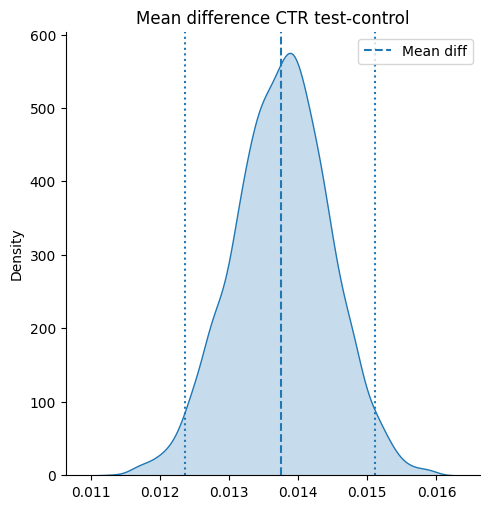

In [ ]:
import matplotlib.pyplot as plt
bootstrap_ctr_diff = np.array(result[4])
plt.figure(figsize=(4,2))
sns.displot(bootstrap_ctr_diff, kind='kde',fill=True)
x = np.linspace(bootstrap_ctr_diff.min(), bootstrap_ctr_diff.max(), 500)
plt.axvline(bootstrap_ctr_diff.mean(), linestyle='--', label='Mean diff')
lower = result[1]
upper = result[2]
plt.axvline(lower, linestyle=':')
plt.axvline(upper, linestyle=':')
plt.title('Mean difference CTR test-control')
plt.legend()
plt.show()

In [25]:
print(f'confidence interval: {lower:.4f} - {upper:.4f}')

confidence interval: 0.0124 - 0.0151


The bootstrap distribution suggests a statistically robust positive treatment effect, with nearly all resampled estimates showing CTR improvement over control. The confidence interval excludes zero, indicating the observed lift is unlikely to be due to random variation alone.

In [ ]:
# use shapiro-wilk test sample mean normality
from scipy.stats import shapiro
stat, p_value = shapiro(bootstrap_ctr_diff)
print(f'stats: {stat:.2f}')
print(f'p_value: {p_value:.2f}')
# With very large datasets, Shapiro–Wilk becomes extremely sensitive and may reject even tiny deviations from normality.
# For CLT demonstrations, visual checks are often more useful:

stats: 1.00
p_value: 0.03


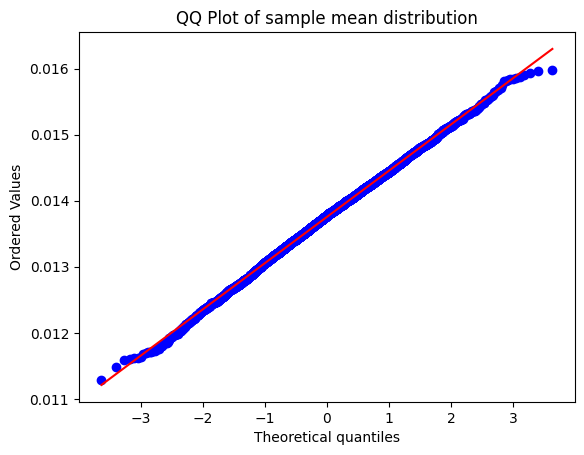

In [18]:
from scipy import stats
stats.probplot(bootstrap_ctr_diff, dist='norm', plot=plt)
plt.title('QQ Plot of sample mean distribution')
plt.show()

## Z Test

In [20]:
# sample size is enough?
sample_check = df.groupby('group').agg(
    mean=('ctr','mean'),
    count=('ctr','count')
).reset_index()
sample_check['size'] = sample_check['mean'] * sample_check['count']
sample_check

,group,mean,count,size
0,control,0.048464,45000,2180.878284
1,test,0.062712,45000,2822.045450


In [22]:
# check n * p = 4500 * 0.05 = 225 large enough to satify CLT condition for z test
from statsmodels.stats.proportion import proportions_ztest
summary = df.groupby('group')[['clicks','views']].sum()
success = np.array([
    summary.loc['test','clicks'],
    summary.loc['control','clicks']
])
nobs = np.array([
    summary.loc['test','views'],
    summary.loc['control','views']
])
z_stat, p_value = proportions_ztest(
    count=success,
    nobs=nobs,
    alternative='two-sided'
)
print(f"Z-statistic: {z_stat:.4f}, P-value: {p_value:.4f}")

Z-statistic: 20.1643, P-value: 0.0000


In [23]:
def manual_ctr_ztest(df,group_col='group', clicks_col='clicks', views_col='views'):
    summary = df.groupby(group_col)[[clicks_col, views_col]].sum().reset_index()
    summary['ctr'] = summary[clicks_col] / summary[views_col]
    p1 = summary.loc[summary[group_col] == 'test', 'ctr'].values[0]
    p2 = summary.loc[summary[group_col] == 'control', 'ctr'].values[0]
    n1 = summary.loc[summary[group_col] == 'test', views_col].values[0]
    n2 = summary.loc[summary[group_col] == 'control', views_col].values[0]
    p_pool = (summary.loc[summary[group_col] == 'test', clicks_col].values[0] + 
              summary.loc[summary[group_col] == 'control', clicks_col].values[0]) / (n1 + n2)
    se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    z_stat = (p1 - p2) / se_pool
    from scipy.stats import norm
    p_value = 2 * (1 - norm.cdf(abs(z_stat)))
    return z_stat, p_value

In [24]:
result = manual_ctr_ztest(df)
print(f"Z-statistic: {result[0]}, P-value: {result[1]}")

Z-statistic: 20.16425842618982, P-value: 0.0


In [26]:
# cohen's d
mean_t=df[df['group']=='test']['ctr'].mean()
mean_c=df[df['group']=='control']['ctr'].mean()
len_t=df[df['group']=='test']['views'].count()
len_c=df[df['group']=='control']['views'].count()
std_t=df[df['group']=='test']['ctr'].std()
std_c=df[df['group']=='control']['ctr'].std()
cohen_d = (mean_t - mean_c) / np.sqrt(((len_t-1)*std_t+(len_c-1)*std_c)/(len_t+len_c-2))
print(f'cohen d effect: {cohen_d:.4f}')

cohen d effect: 0.0375
